## APPLIED STATISTICS

### Turma 16DTSR


#### Trabalho prático usando o Python

#### Habilidades desenvolvidas: Análise Exploratória de Dados. Detecção de outliers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [34]:
#lendo a base de dados
cadastro = pd.read_csv('Data/cadastro.csv').drop(columns=['Unnamed: 0'])

In [35]:
# Johann -> Análise Exploratória de Dados (AED)

import sweetviz as sv

report = sv.analyze(cadastro)
report.show_html()

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [37]:
cadastro.columns

Index(['NUM_CPF', 'CHAVE_CONTRATO', 'DATA_NASCIMENTO', 'RENDA_PRESUMIDA',
       'CEP', 'LOGRADOURO', 'NUMERO', 'COMPLEMENTO', 'CEP_A', 'BAIRRO',
       'CIDADE', 'UF', 'LATITUDE', 'LONGITUDE', 'DDD_CELULAR', 'CELULAR',
       'DDD_CELULAR_2', 'CELULAR_2', 'COD_BANCO', 'NUM_AGENCIA', 'NUM_CONTA',
       'MARCA_VEICULO', 'MODELO_VEICULO', 'PLACA_VEICULO', 'CNPJ_CREDOR',
       'VALOR_DIVIDA', 'STATUS_CONSENTIMENTO', 'DATA_INCLUSAO1', 'IDADE'],
      dtype='object')

In [4]:
#visualizando o conteúdo da base
#cadastro.head()
cadastro.head().T

,0,1,2,3,4
Unnamed: 0,1,2,3,4,5
NUM_CPF,40977545806,72544350725,10536099812,1471742873,954396332
CHAVE_CONTRATO,1,2,3,4,5
DATA_NASCIMENTO,25/09/1996,10/03/1961,28/11/1965,02/05/1959,10/11/1984
RENDA_PRESUMIDA,1890000.0,1333890.24,22000.0,16000.0,15929.0
CEP,2471020,1319001,4323120,4136030,8452105
LOGRADOURO,R AUGUSTO VIANA DE CASTELO,R MARIA PAULA,R DAS JOIAS,R GUARAREMA,R JOAO DE SIQUEIRA AFONSO
NUMERO,26.0,201.0,202.0,430.0,709.0
COMPLEMENTO,NaN,AP 52,VL DO,NaN,CAS
CEP_A,2471020,1319001,4323120,4136030,8452105


In [5]:
#formato das variáveis
cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            426 non-null    int64  
 1   NUM_CPF               426 non-null    int64  
 2   CHAVE_CONTRATO        426 non-null    int64  
 3   DATA_NASCIMENTO       426 non-null    object 
 4   RENDA_PRESUMIDA       426 non-null    float64
 5   CEP                   426 non-null    int64  
 6   LOGRADOURO            426 non-null    object 
 7   NUMERO                425 non-null    float64
 8   COMPLEMENTO           206 non-null    object 
 9   CEP_A                 426 non-null    int64  
 10  BAIRRO                390 non-null    object 
 11  CIDADE                426 non-null    object 
 12  UF                    426 non-null    object 
 13  LATITUDE              389 non-null    float64
 14  LONGITUDE             389 non-null    float64
 15  DDD_CELULAR           2

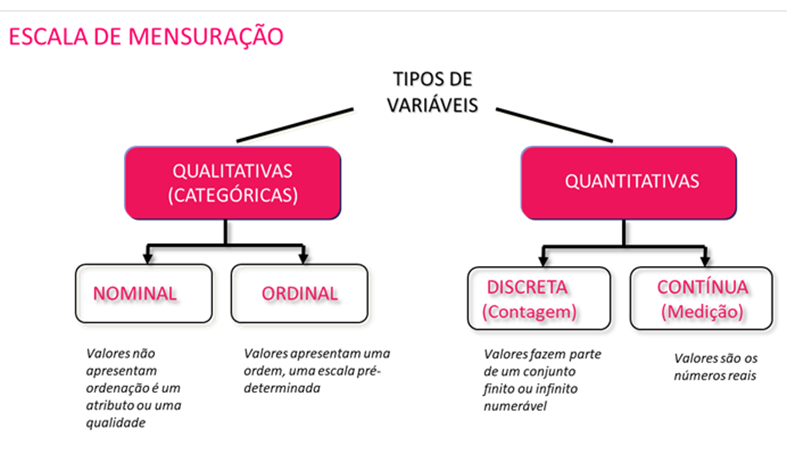

In [6]:
# contagem de observações com dados
cadastro.count()

Unnamed: 0              426
NUM_CPF                 426
CHAVE_CONTRATO          426
DATA_NASCIMENTO         426
RENDA_PRESUMIDA         426
CEP                     426
LOGRADOURO              426
NUMERO                  425
COMPLEMENTO             206
CEP_A                   426
BAIRRO                  390
CIDADE                  426
UF                      426
LATITUDE                389
LONGITUDE               389
DDD_CELULAR             275
CELULAR                 275
DDD_CELULAR_2           170
CELULAR_2               170
COD_BANCO               308
NUM_AGENCIA             308
NUM_CONTA               308
MARCA_VEICULO             2
MODELO_VEICULO            2
PLACA_VEICULO             2
CNPJ_CREDOR             421
VALOR_DIVIDA            426
STATUS_CONSENTIMENTO    426
DATA_INCLUSAO1          421
IDADE                   421
dtype: int64

In [7]:
# contagem de observações diferentes
cadastro.nunique()

Unnamed: 0              426
NUM_CPF                 311
CHAVE_CONTRATO          426
DATA_NASCIMENTO         305
RENDA_PRESUMIDA         317
CEP                     310
LOGRADOURO              308
NUMERO                  241
COMPLEMENTO              86
CEP_A                   310
BAIRRO                  230
CIDADE                    1
UF                        1
LATITUDE                282
LONGITUDE               282
DDD_CELULAR              18
CELULAR                 202
DDD_CELULAR_2            14
CELULAR_2               124
COD_BANCO                17
NUM_AGENCIA             294
NUM_CONTA               308
MARCA_VEICULO             2
MODELO_VEICULO            2
PLACA_VEICULO             2
CNPJ_CREDOR             153
VALOR_DIVIDA            235
STATUS_CONSENTIMENTO      1
DATA_INCLUSAO1          405
IDADE                    54
dtype: int64

In [8]:
# é missing ou não ( NA Not Avaliable)
# Retorna verdadeiro ou falso para presença de dados faltantes (missing value)
cadastro.isna().T

,0,1,2,3,4,5,6,7,8,9,...,416,417,418,419,420,421,422,423,424,425
Unnamed: 0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
NUM_CPF,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
CHAVE_CONTRATO,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
DATA_NASCIMENTO,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
RENDA_PRESUMIDA,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
CEP,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
LOGRADOURO,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
NUMERO,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
COMPLEMENTO,True,False,False,True,False,False,True,True,True,False,...,True,True,False,True,False,True,False,True,False,False
CEP_A,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Contagem de observações com missing
cadastro.isna().sum()

Unnamed: 0                0
NUM_CPF                   0
CHAVE_CONTRATO            0
DATA_NASCIMENTO           0
RENDA_PRESUMIDA           0
CEP                       0
LOGRADOURO                0
NUMERO                    1
COMPLEMENTO             220
CEP_A                     0
BAIRRO                   36
CIDADE                    0
UF                        0
LATITUDE                 37
LONGITUDE                37
DDD_CELULAR             151
CELULAR                 151
DDD_CELULAR_2           256
CELULAR_2               256
COD_BANCO               118
NUM_AGENCIA             118
NUM_CONTA               118
MARCA_VEICULO           424
MODELO_VEICULO          424
PLACA_VEICULO           424
CNPJ_CREDOR               5
VALOR_DIVIDA              0
STATUS_CONSENTIMENTO      0
DATA_INCLUSAO1            5
IDADE                     5
dtype: int64

In [43]:
cadastro[cadastro["DATA_INCLUSAO1"].isna()].T

,3,5,8,199,324
NUM_CPF,1471742873,6047033849,91758610972,30719081807,27886970829
CHAVE_CONTRATO,4,6,9,200,325
DATA_NASCIMENTO,02/05/1959,13/10/1940,05/12/1976,27/12/1982,18/09/1980
RENDA_PRESUMIDA,16000.00,15790.12,13673.80,2473.86,2051.64
CEP,4136030,4241100,2531010,8235030,8410130
LOGRADOURO,R GUARAREMA,R ROMEU TARZIA,R JOSE DE OLIVEIRA,R FITA DE MOCA,R COMANDANTE CARLOS RUHL
NUMERO,430.00,94.00,1172.00,214.00,736.00
COMPLEMENTO,NaN,CS 2,NaN,CS 1,NaN
CEP_A,4136030,4241100,2531010,8235030,8410130
BAIRRO,BOSQUE DA SAUDE,SAO JOAO CLIMACO,PARQUE PERUCHE,VILA VERDE,VILA PRINCESA ISABEL


In [45]:
cadastro.groupby(cadastro["DATA_INCLUSAO1"].isna()).mean(numeric_only=True)

cadastro[cadastro["DATA_INCLUSAO1"].isna()].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_CPF,5.00,31576688066.00,36035691737.36,1471742873.00,6047033849.00,27886970829.00,30719081807.00,91758610972.00
CHAVE_CONTRATO,5.00,108.80,147.11,4.00,6.00,9.00,200.00,325.00
RENDA_PRESUMIDA,5.00,9997.88,7121.12,2051.64,2473.86,13673.80,15790.12,16000.00
CEP,5.00,5510660.00,2655598.92,2531010.00,4136030.00,4241100.00,8235030.00,8410130.00
NUMERO,5.00,529.20,434.32,94.00,214.00,430.00,736.00,1172.00
CEP_A,5.00,5510660.00,2655598.92,2531010.00,4136030.00,4241100.00,8235030.00,8410130.00
LATITUDE,5.00,-23.56,0.06,-23.62,-23.61,-23.55,-23.52,-23.49
LONGITUDE,5.00,-46.55,0.10,-46.65,-46.63,-46.59,-46.45,-46.42
DDD_CELULAR,4.00,11.00,0.00,11.00,11.00,11.00,11.00,11.00
CELULAR,4.00,969592560.50,10809457.06,962555876.00,964044398.00,965058481.50,970606644.00,985697403.00


In [46]:
cadastro[cadastro["DATA_INCLUSAO1"].isna()].describe()

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE
count,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,4.00,4.00,1.00,1.00,4.00,4.00,4.00,0.00,5.00,5.00,0.00
mean,31576688066.00,108.80,9997.88,5510660.00,529.20,5510660.00,-23.56,-46.55,11.00,969592560.50,11.00,982186579.00,204.75,3528.00,350352.00,NaN,0.00,1.00,NaN
std,36035691737.36,147.11,7121.12,2655598.92,434.32,2655598.92,0.06,0.10,0.00,10809457.06,NaN,NaN,159.98,2290.63,516501.15,NaN,0.00,0.00,NaN
min,1471742873.00,4.00,2051.64,2531010.00,94.00,2531010.00,-23.62,-46.65,11.00,962555876.00,11.00,982186579.00,33.00,1475.00,8459.00,NaN,0.00,1.00,NaN
25%,6047033849.00,6.00,2473.86,4136030.00,214.00,4136030.00,-23.61,-46.63,11.00,964044398.00,11.00,982186579.00,86.25,1756.25,16301.75,NaN,0.00,1.00,NaN
50%,27886970829.00,9.00,13673.80,4241100.00,430.00,4241100.00,-23.55,-46.59,11.00,965058481.50,11.00,982186579.00,222.50,3154.00,144731.50,NaN,0.00,1.00,NaN
75%,30719081807.00,200.00,15790.12,8235030.00,736.00,8235030.00,-23.52,-46.45,11.00,970606644.00,11.00,982186579.00,341.00,4925.75,478781.75,NaN,0.00,1.00,NaN
max,91758610972.00,325.00,16000.00,8410130.00,1172.00,8410130.00,-23.49,-46.42,11.00,985697403.00,11.00,982186579.00,341.00,6329.00,1103486.00,NaN,0.00,1.00,NaN


In [47]:
cadastro[cadastro["DATA_INCLUSAO1"].notna()].describe()

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE
count,421.00,421.00,421.00,421.00,420.00,421.00,384.00,384.00,271.00,271.00,169.00,169.00,304.00,304.00,304.00,421.00,421.00,421.00,421.00
mean,26774134524.80,214.74,10392.44,4624815.09,596.07,4624815.09,-23.58,-46.61,16.58,976842034.00,18.30,960262098.80,189.56,2557.95,52540309.51,31873758302107.55,215396.69,1.00,45.74
std,18918276973.31,122.48,112445.17,1971300.50,4898.38,1971300.50,0.08,0.11,17.90,56721120.57,19.63,138563110.47,176.21,2349.64,472064544.73,22283968587101.66,2215023.51,0.00,107.73
min,94700508.00,1.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,11.00,77151941.00,1.00,1.00,290.00,113451000135.00,103.00,1.00,17.00
25%,11251609856.00,109.00,2068.00,3149000.00,57.00,3149000.00,-23.63,-46.68,11.00,969874429.00,11.00,973494957.00,33.00,554.75,15030.00,8623036000133.00,205.00,1.00,30.00
50%,25937742826.00,215.00,2430.00,4323120.00,160.00,4323120.00,-23.57,-46.64,11.00,982536548.00,11.00,982348810.00,237.00,1900.00,53951.00,40432544000147.00,368.00,1.00,37.00
75%,35798933865.00,320.00,2894.78,5596070.00,421.00,5596070.00,-23.51,-46.52,11.00,992497873.00,11.00,993495586.00,341.00,3773.00,488489.25,43374768000138.00,981.00,1.00,46.00
max,99921022504.00,426.00,1890000.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,98.00,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00


In [10]:
# % de observações com missing
cadastro.isna().sum()/len(cadastro)*100

Unnamed: 0               0.000000
NUM_CPF                  0.000000
CHAVE_CONTRATO           0.000000
DATA_NASCIMENTO          0.000000
RENDA_PRESUMIDA          0.000000
CEP                      0.000000
LOGRADOURO               0.000000
NUMERO                   0.234742
COMPLEMENTO             51.643192
CEP_A                    0.000000
BAIRRO                   8.450704
CIDADE                   0.000000
UF                       0.000000
LATITUDE                 8.685446
LONGITUDE                8.685446
DDD_CELULAR             35.446009
CELULAR                 35.446009
DDD_CELULAR_2           60.093897
CELULAR_2               60.093897
COD_BANCO               27.699531
NUM_AGENCIA             27.699531
NUM_CONTA               27.699531
MARCA_VEICULO           99.530516
MODELO_VEICULO          99.530516
PLACA_VEICULO           99.530516
CNPJ_CREDOR              1.173709
VALOR_DIVIDA             0.000000
STATUS_CONSENTIMENTO     0.000000
DATA_INCLUSAO1           1.173709
IDADE         

In [11]:
# Descritivo das variáveis - medidas resumo  De todas as variáveis numéricas

#cadastro.describe()
cadastro.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,426.0,2.135000e+02,1.231199e+02,1.000000e+00,1.072500e+02,2.135000e+02,3.197500e+02,4.260000e+02
NUM_CPF,426.0,2.683050e+10,1.913585e+10,9.470051e+07,1.086907e+10,2.604114e+10,3.579893e+10,9.992102e+10
CHAVE_CONTRATO,426.0,2.135000e+02,1.231199e+02,1.000000e+00,1.072500e+02,2.135000e+02,3.197500e+02,4.260000e+02
RENDA_PRESUMIDA,426.0,1.038781e+04,1.117839e+05,0.000000e+00,2.068500e+03,2.431580e+03,2.923545e+03,1.890000e+06
CEP,426.0,4.635212e+06,1.978839e+06,1.007020e+06,3.153250e+06,4.323120e+06,5.644782e+06,8.490018e+06
NUMERO,425.0,5.952871e+02,4.869597e+03,3.000000e+00,5.800000e+01,1.640000e+02,4.300000e+02,9.999900e+04
CEP_A,426.0,4.635212e+06,1.978839e+06,1.007020e+06,3.153250e+06,4.323120e+06,5.644782e+06,8.490018e+06
LATITUDE,389.0,-2.357658e+01,8.417755e-02,-2.380206e+01,-2.363061e+01,-2.356434e+01,-2.350625e+01,-2.343125e+01
LONGITUDE,389.0,-4.660483e+01,1.139617e-01,-4.680850e+01,-4.668348e+01,-4.663475e+01,-4.651564e+01,-4.638065e+01
DDD_CELULAR,275.0,1.650182e+01,1.777975e+01,1.100000e+01,1.100000e+01,1.100000e+01,1.100000e+01,9.800000e+01


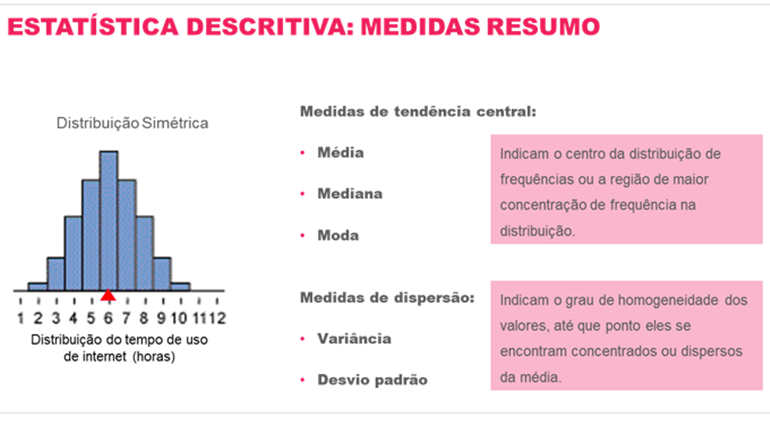

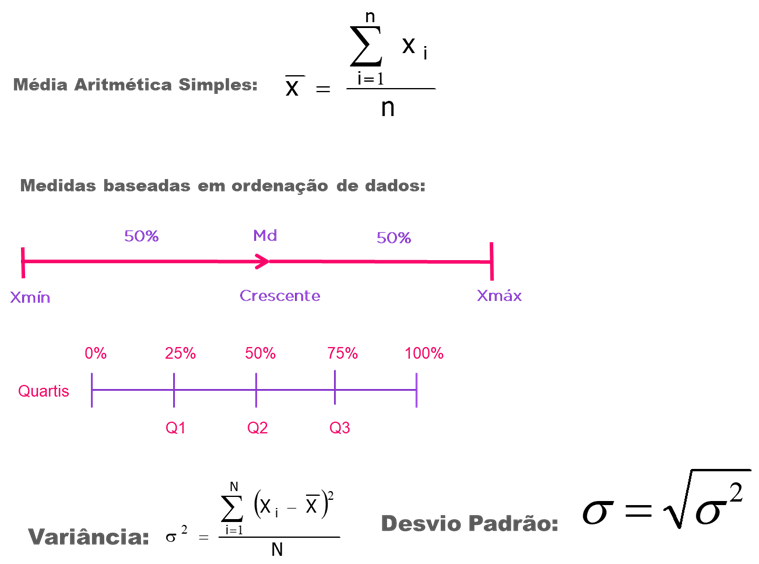

In [12]:
# colocando as medidas resumo em um objeto
Describe=cadastro.describe()
print(Describe)

       Unnamed: 0       NUM_CPF  CHAVE_CONTRATO  RENDA_PRESUMIDA  \
count   426.00000  4.260000e+02       426.00000     4.260000e+02   
mean    213.50000  2.683050e+10       213.50000     1.038781e+04   
std     123.11986  1.913585e+10       123.11986     1.117839e+05   
min       1.00000  9.470051e+07         1.00000     0.000000e+00   
25%     107.25000  1.086907e+10       107.25000     2.068500e+03   
50%     213.50000  2.604114e+10       213.50000     2.431580e+03   
75%     319.75000  3.579893e+10       319.75000     2.923545e+03   
max     426.00000  9.992102e+10       426.00000     1.890000e+06   

                CEP        NUMERO         CEP_A    LATITUDE   LONGITUDE  \
count  4.260000e+02    425.000000  4.260000e+02  389.000000  389.000000   
mean   4.635212e+06    595.287059  4.635212e+06  -23.576581  -46.604831   
std    1.978839e+06   4869.596821  1.978839e+06    0.084178    0.113962   
min    1.007020e+06      3.000000  1.007020e+06  -23.802055  -46.808504   
25%    3.153

In [13]:
pd.set_option('display.float_format','{:.2f}'.format)

In [14]:
Describe=cadastro.describe().round(0)
print(Describe)

       Unnamed: 0        NUM_CPF  CHAVE_CONTRATO  RENDA_PRESUMIDA        CEP  \
count      426.00         426.00          426.00           426.00     426.00   
mean       214.00 26830502524.00          214.00         10388.00 4635212.00   
std        123.00 19135846184.00          123.00        111784.00 1978839.00   
min          1.00    94700508.00            1.00             0.00 1007020.00   
25%        107.00 10869067862.00          107.00          2068.00 3153250.00   
50%        214.00 26041138816.00          214.00          2432.00 4323120.00   
75%        320.00 35798933865.00          320.00          2924.00 5644782.00   
max        426.00 99921022504.00          426.00       1890000.00 8490018.00   

        NUMERO      CEP_A  LATITUDE  LONGITUDE  DDD_CELULAR      CELULAR  \
count   425.00     426.00    389.00     389.00       275.00       275.00   
mean    595.00 4635212.00    -24.00     -47.00        17.00 976736587.00   
std    4870.00 1978839.00      0.00       0.00     

In [15]:
#Preprocessing
# mudar o formato da variável number para string
cadastro['NUM_CPF'] = cadastro['NUM_CPF'].astype(str)
cadastro['CHAVE_CONTRATO'] = cadastro['CHAVE_CONTRATO'].astype(str)
cadastro['CEP'] = cadastro['CEP'].astype(str)
cadastro['CEP_A'] = cadastro['CEP_A'].astype(str)
cadastro['NUMERO'] = cadastro['NUMERO'].astype(str)
cadastro['LATITUDE'] = cadastro['LATITUDE'].astype(str)
cadastro['LONGITUDE'] = cadastro['LONGITUDE'].astype(str)
cadastro['CELULAR'] = cadastro['CELULAR'].astype(str)
cadastro['DDD_CELULAR'] = cadastro['DDD_CELULAR'].astype(str)
cadastro['CELULAR_2'] = cadastro['CELULAR_2'].astype(str)
cadastro['DDD_CELULAR_2'] = cadastro['DDD_CELULAR_2'].astype(str)
cadastro['COD_BANCO'] = cadastro['COD_BANCO'].astype(str)
cadastro['NUM_AGENCIA'] = cadastro['NUM_AGENCIA'].astype(str)
cadastro['NUM_CONTA'] = cadastro['NUM_CONTA'].astype(str)
cadastro['CNPJ_CREDOR'] = cadastro['CNPJ_CREDOR'].astype(str)
cadastro['STATUS_CONSENTIMENTO'] = cadastro['STATUS_CONSENTIMENTO'].astype(str)



In [16]:
# avaliando as alterações feitas nos formatos das variáveis
cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            426 non-null    int64  
 1   NUM_CPF               426 non-null    object 
 2   CHAVE_CONTRATO        426 non-null    object 
 3   DATA_NASCIMENTO       426 non-null    object 
 4   RENDA_PRESUMIDA       426 non-null    float64
 5   CEP                   426 non-null    object 
 6   LOGRADOURO            426 non-null    object 
 7   NUMERO                426 non-null    object 
 8   COMPLEMENTO           206 non-null    object 
 9   CEP_A                 426 non-null    object 
 10  BAIRRO                390 non-null    object 
 11  CIDADE                426 non-null    object 
 12  UF                    426 non-null    object 
 13  LATITUDE              426 non-null    object 
 14  LONGITUDE             426 non-null    object 
 15  DDD_CELULAR           4

In [17]:
# descritivo das variáveis após as alterações realizadas
cadastro.describe().round(2)

,Unnamed: 0,RENDA_PRESUMIDA,VALOR_DIVIDA,IDADE
count,426.00,426.00,426.00,421.00
mean,213.50,10387.81,212868.56,45.74
std,123.12,111783.91,2202077.89,107.73
min,1.00,0.00,0.00,17.00
25%,107.25,2068.50,198.50,30.00
50%,213.50,2431.58,360.00,37.00
75%,319.75,2923.54,981.00,46.00
max,426.00,1890000.00,28072009.00,2006.00


In [18]:
cadastro.isna().sum()

Unnamed: 0                0
NUM_CPF                   0
CHAVE_CONTRATO            0
DATA_NASCIMENTO           0
RENDA_PRESUMIDA           0
CEP                       0
LOGRADOURO                0
NUMERO                    0
COMPLEMENTO             220
CEP_A                     0
BAIRRO                   36
CIDADE                    0
UF                        0
LATITUDE                  0
LONGITUDE                 0
DDD_CELULAR               0
CELULAR                   0
DDD_CELULAR_2             0
CELULAR_2                 0
COD_BANCO                 0
NUM_AGENCIA               0
NUM_CONTA                 0
MARCA_VEICULO           424
MODELO_VEICULO          424
PLACA_VEICULO           424
CNPJ_CREDOR               0
VALOR_DIVIDA              0
STATUS_CONSENTIMENTO      0
DATA_INCLUSAO1            5
IDADE                     5
dtype: int64

In [19]:
# observando alguns campos...
cadastro.head(5).T

,0,1,2,3,4
Unnamed: 0,1,2,3,4,5
NUM_CPF,40977545806,72544350725,10536099812,1471742873,954396332
CHAVE_CONTRATO,1,2,3,4,5
DATA_NASCIMENTO,25/09/1996,10/03/1961,28/11/1965,02/05/1959,10/11/1984
RENDA_PRESUMIDA,1890000.00,1333890.24,22000.00,16000.00,15929.00
CEP,2471020,1319001,4323120,4136030,8452105
LOGRADOURO,R AUGUSTO VIANA DE CASTELO,R MARIA PAULA,R DAS JOIAS,R GUARAREMA,R JOAO DE SIQUEIRA AFONSO
NUMERO,26.0,201.0,202.0,430.0,709.0
COMPLEMENTO,NaN,AP 52,VL DO,NaN,CAS
CEP_A,2471020,1319001,4323120,4136030,8452105


In [20]:
# indicando e alterando campos
# Mudar a categoria "nan" para "NaN" (identificação de missing data)
# isto aconteceu quando mudamos o formato de algumas variáveis

cadastro.replace('nan', np.nan, inplace=True)

In [21]:
cadastro.head(5).T

,0,1,2,3,4
Unnamed: 0,1,2,3,4,5
NUM_CPF,40977545806,72544350725,10536099812,1471742873,954396332
CHAVE_CONTRATO,1,2,3,4,5
DATA_NASCIMENTO,25/09/1996,10/03/1961,28/11/1965,02/05/1959,10/11/1984
RENDA_PRESUMIDA,1890000.00,1333890.24,22000.00,16000.00,15929.00
CEP,2471020,1319001,4323120,4136030,8452105
LOGRADOURO,R AUGUSTO VIANA DE CASTELO,R MARIA PAULA,R DAS JOIAS,R GUARAREMA,R JOAO DE SIQUEIRA AFONSO
NUMERO,26.0,201.0,202.0,430.0,709.0
COMPLEMENTO,NaN,AP 52,VL DO,NaN,CAS
CEP_A,2471020,1319001,4323120,4136030,8452105


In [22]:
cadastro.isna().sum()

Unnamed: 0                0
NUM_CPF                   0
CHAVE_CONTRATO            0
DATA_NASCIMENTO           0
RENDA_PRESUMIDA           0
CEP                       0
LOGRADOURO                0
NUMERO                    1
COMPLEMENTO             220
CEP_A                     0
BAIRRO                   36
CIDADE                    0
UF                        0
LATITUDE                 37
LONGITUDE                37
DDD_CELULAR             151
CELULAR                 151
DDD_CELULAR_2           256
CELULAR_2               256
COD_BANCO               118
NUM_AGENCIA             118
NUM_CONTA               118
MARCA_VEICULO           424
MODELO_VEICULO          424
PLACA_VEICULO           424
CNPJ_CREDOR               5
VALOR_DIVIDA              0
STATUS_CONSENTIMENTO      0
DATA_INCLUSAO1            5
IDADE                     5
dtype: int64

In [23]:
cadastro.isna().sum()/len(cadastro)*100

Unnamed: 0              0.00
NUM_CPF                 0.00
CHAVE_CONTRATO          0.00
DATA_NASCIMENTO         0.00
RENDA_PRESUMIDA         0.00
CEP                     0.00
LOGRADOURO              0.00
NUMERO                  0.23
COMPLEMENTO            51.64
CEP_A                   0.00
BAIRRO                  8.45
CIDADE                  0.00
UF                      0.00
LATITUDE                8.69
LONGITUDE               8.69
DDD_CELULAR            35.45
CELULAR                35.45
DDD_CELULAR_2          60.09
CELULAR_2              60.09
COD_BANCO              27.70
NUM_AGENCIA            27.70
NUM_CONTA              27.70
MARCA_VEICULO          99.53
MODELO_VEICULO         99.53
PLACA_VEICULO          99.53
CNPJ_CREDOR             1.17
VALOR_DIVIDA            0.00
STATUS_CONSENTIMENTO    0.00
DATA_INCLUSAO1          1.17
IDADE                   1.17
dtype: float64

In [24]:
!pip install missingno
import missingno as msno

# Visualizando os dados faltantes? A biblioteca MissingNo permite a visualização dos dados nulos (‘NaN’) em seu dataset

<Axes: >

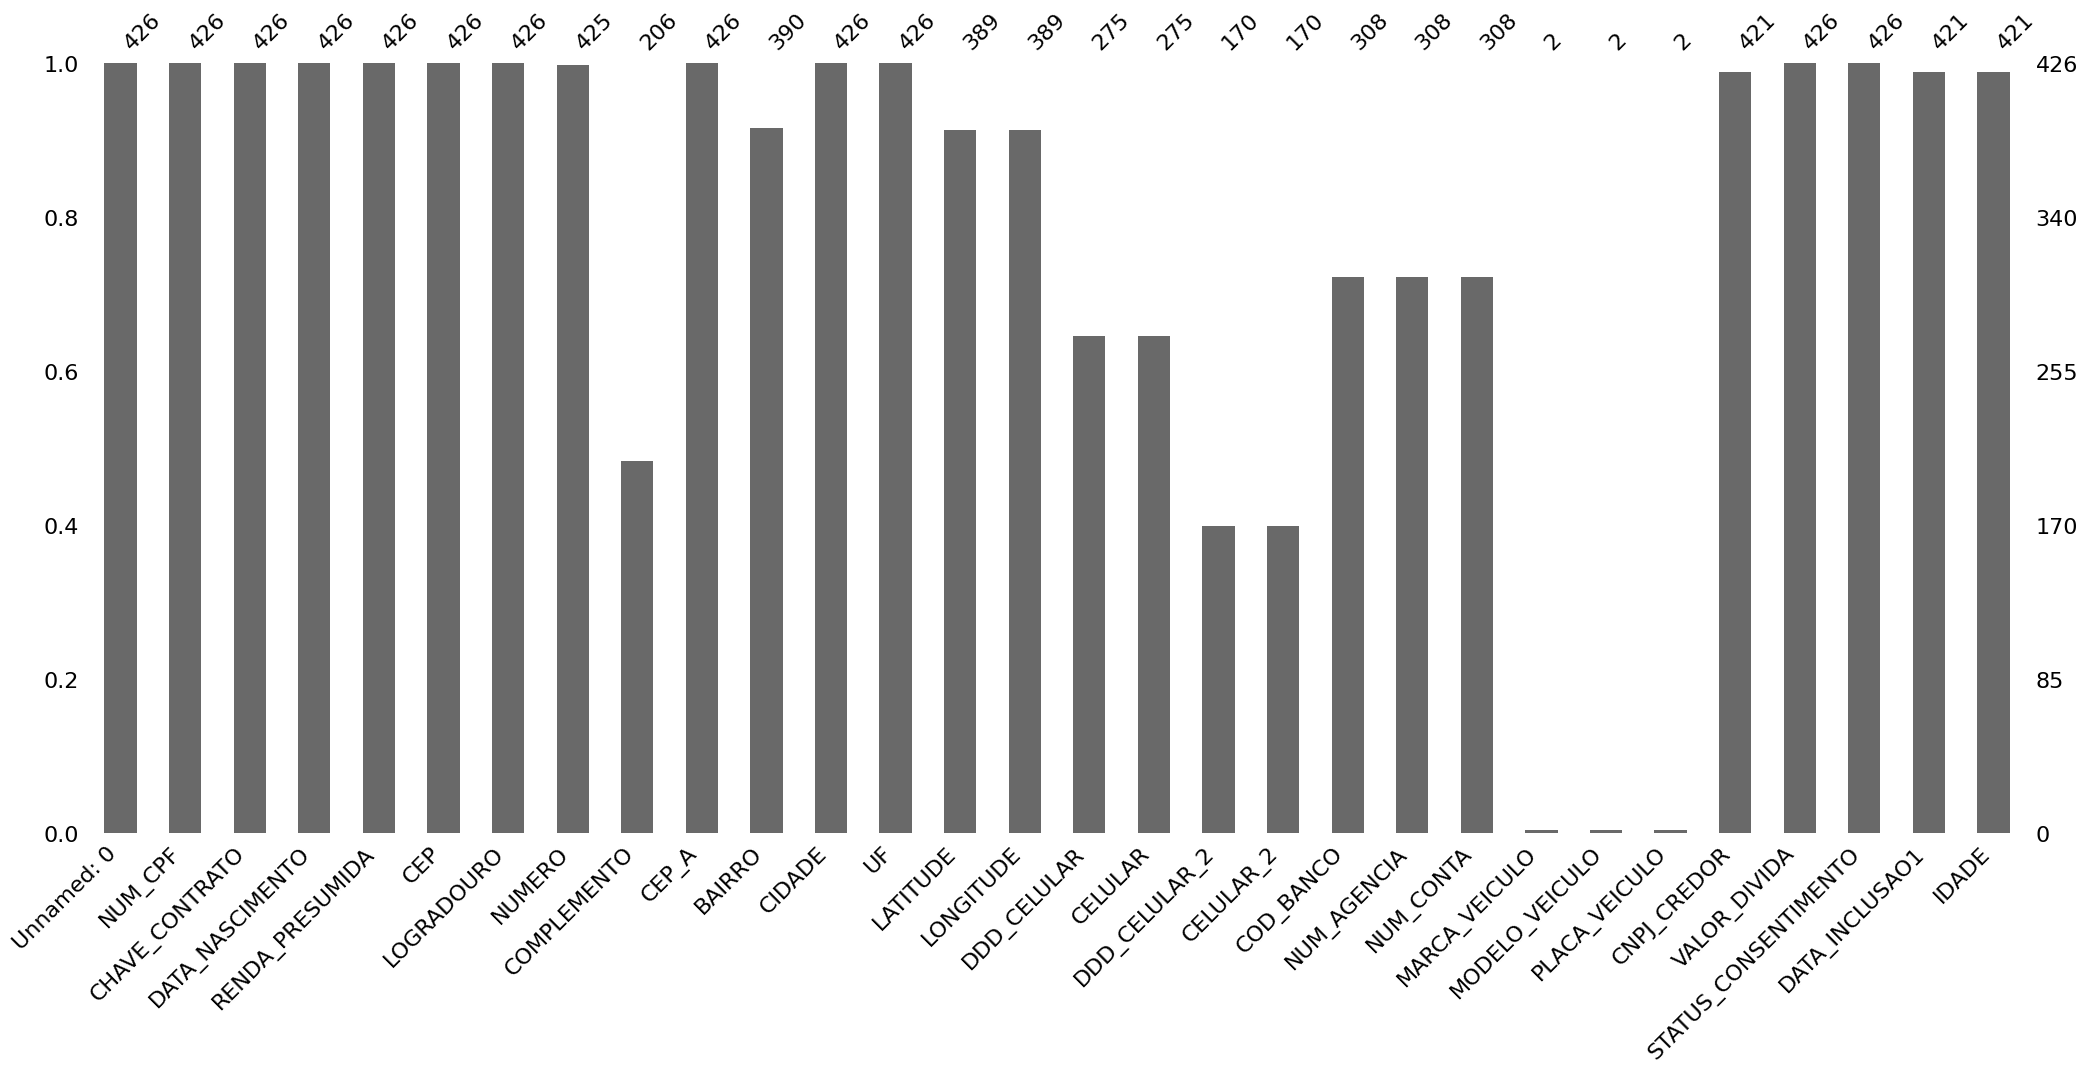

In [25]:
# Análise da completude das variáveis do banco de dados usando o gráfico de barra. No eixo "Y" é a frequência relativa e no
# eixo "X" as variáveis.
msno.bar(cadastro)

<Axes: >

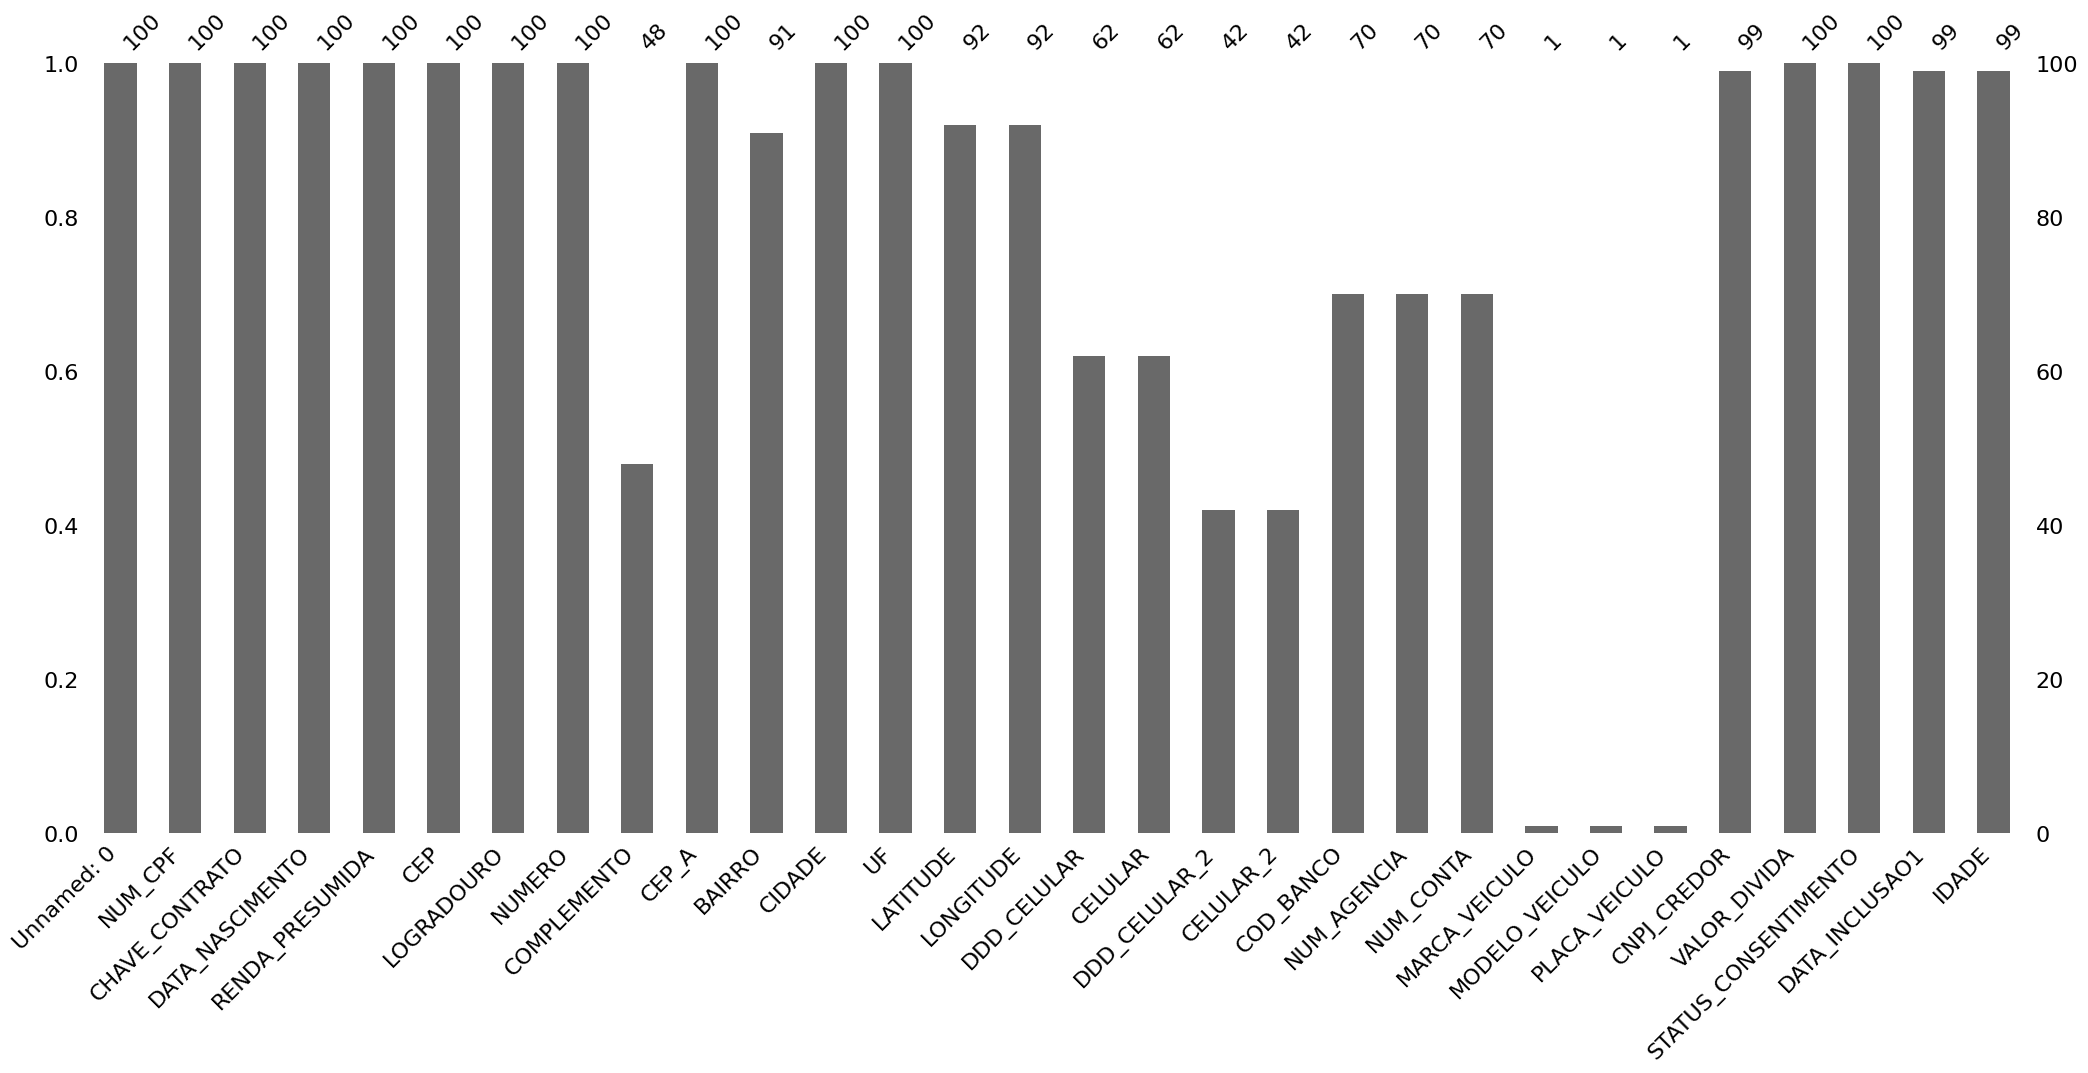

In [26]:
# Análise da completude das variáveis em uma amostra de tamanho 100 (n=100) do banco de dados usando o gráfico de barra.
# No eixo "Y" é a frequência relativa e no eixo "X" as variáveis.

msno.bar(cadastro.sample(100))

## Imputação de dados faltantes

In [27]:
cadastro["IDADE"].describe()

# Idade é uma variável que encontramos com 5 dados faltantes

count    421.00
mean      45.74
std      107.73
min       17.00
25%       30.00
50%       37.00
75%       46.00
max     2006.00
Name: IDADE, dtype: float64

O que podemos fazer quando nossas variáveis tem dados faltantes?

Avaliar a quantidade de valores missing presente na variável, e eliminá-los caso tenha um “alto” percentual.

Tratamento de valores missing:
    Eliminar todo o registro (toda a linha), ou coluna (campo) de variável que contenha valores faltantes.
    ==> Processo simples porém há perda de informação.
    Variáveis Quantitativas,  a mais simples, é o uso da média ou mediana.
    ==> Use a média ou mediana da variável por algum tipo de classificação das entidades.
    ==> Exemplo: mesma região, mesmo segmento, mesma classe social, mesmo sexo, etc.
    Usar técnicas mais avançadas para estimar os campos, técnicas mais usadas: Análise de Regressão,
    Árvores de  Regressão, KNN ou outras imputações com machine learning.


In [28]:

print("Media :",np.mean(cadastro['IDADE']))
print("Mediana :",(cadastro['IDADE'].median()))

print("Minimo :",np.min(cadastro['IDADE']))
print("Maximo :",np.max(cadastro['IDADE']))


Media : 45.736342042755346
Mediana : 37.0
Minimo : 17.0
Maximo : 2006.0


In [29]:
# avalie a variabilidade da variável
print("desvio :",np.std(cadastro['IDADE']))

desvio : 107.60036174614845


In [30]:
# percebam que estamos utilizando uma medida com dados incoerentes, o que fazer?

In [50]:
# Imputação de dados faltantes usando a media? ou qual métrica?

cadastro['Idade_i'] = cadastro['IDADE'].fillna(value=cadastro['IDADE'].mean())


In [51]:
# Análise descritiva das variáveis
cadastro.describe().round(2)

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE,Idade_i
count,426.00,426.00,426.00,426.00,425.00,426.00,389.00,389.00,275.00,275.00,170.00,170.00,308.00,308.00,308.00,421.00,426.00,426.00,421.00,426.00
mean,26830502524.11,213.50,10387.81,4635212.33,595.29,4635212.33,-23.58,-46.60,16.50,976736587.11,18.26,960391066.33,189.76,2570.55,51862517.85,31873758302107.56,212868.56,1.00,45.74,45.74
std,19135846183.67,123.12,111783.91,1978839.32,4869.60,1978839.32,0.08,0.11,17.78,56323647.16,19.58,138162785.25,175.78,2347.82,469016468.99,22283968587101.66,2202077.89,0.00,107.73,107.09
min,94700508.00,1.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,11.00,77151941.00,1.00,1.00,290.00,113451000135.00,0.00,1.00,17.00,17.00
25%,10869067862.00,107.25,2068.50,3153250.25,58.00,3153250.25,-23.63,-46.68,11.00,969555131.50,11.00,973504991.25,33.00,563.25,15030.00,8623036000133.00,198.50,1.00,30.00,30.00
50%,26041138816.00,213.50,2431.58,4323120.00,164.00,4323120.00,-23.56,-46.63,11.00,982497429.00,11.00,982267694.50,237.00,1900.00,53951.00,40432544000147.00,360.00,1.00,37.00,37.00
75%,35798933865.00,319.75,2923.54,5644782.50,430.00,5644782.50,-23.51,-46.52,11.00,992424488.50,11.00,993495586.00,341.00,3781.00,488489.25,43374768000138.00,981.00,1.00,46.00,46.00
max,99921022504.00,426.00,1890000.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,98.00,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00,2006.00


In [52]:
cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NUM_CPF               426 non-null    int64  
 1   CHAVE_CONTRATO        426 non-null    int64  
 2   DATA_NASCIMENTO       426 non-null    object 
 3   RENDA_PRESUMIDA       426 non-null    float64
 4   CEP                   426 non-null    int64  
 5   LOGRADOURO            426 non-null    object 
 6   NUMERO                425 non-null    float64
 7   COMPLEMENTO           206 non-null    object 
 8   CEP_A                 426 non-null    int64  
 9   BAIRRO                390 non-null    object 
 10  CIDADE                426 non-null    object 
 11  UF                    426 non-null    object 
 12  LATITUDE              389 non-null    float64
 13  LONGITUDE             389 non-null    float64
 14  DDD_CELULAR           275 non-null    float64
 15  CELULAR               2

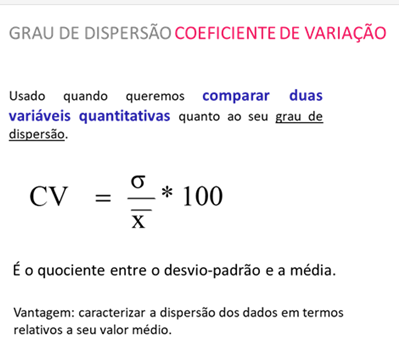

In [53]:
# CV = desvio padrão/média

desc = cadastro.describe().T

desc['CV'] = desc['std']/desc['mean']*100

In [54]:
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,CV
NUM_CPF,426.00,26830502524.11,19135846183.67,94700508.00,10869067862.00,26041138816.00,35798933865.00,99921022504.00,71.32
CHAVE_CONTRATO,426.00,213.50,123.12,1.00,107.25,213.50,319.75,426.00,57.67
RENDA_PRESUMIDA,426.00,10387.81,111783.91,0.00,2068.50,2431.58,2923.54,1890000.00,1076.11
CEP,426.00,4635212.33,1978839.32,1007020.00,3153250.25,4323120.00,5644782.50,8490018.00,42.69
NUMERO,425.00,595.29,4869.60,3.00,58.00,164.00,430.00,99999.00,818.02
CEP_A,426.00,4635212.33,1978839.32,1007020.00,3153250.25,4323120.00,5644782.50,8490018.00,42.69
LATITUDE,389.00,-23.58,0.08,-23.80,-23.63,-23.56,-23.51,-23.43,-0.36
LONGITUDE,389.00,-46.60,0.11,-46.81,-46.68,-46.63,-46.52,-46.38,-0.24
DDD_CELULAR,275.00,16.50,17.78,11.00,11.00,11.00,11.00,98.00,107.74
CELULAR,275.00,976736587.11,56323647.16,78462120.00,969555131.50,982497429.00,992424488.50,999993969.00,5.77


### Interpretação do CV



         Renda presumida:
         O desvio padrão é 10.76 vezes o valor da média. Isso indica presença de outliers. Quantos outliers?

         Recomendado é até 0,3 ou 30%. Valores acima de 30% indicam presença de outliers. (Critério do IBGE)
    


## Histograma e o Boxplot

### são gráficos que representam a distribuição de um conjunto de dados
### O histograma é um gráfico de "barras", enquanto o boxplot é um diagrama de caixa


### Histograma

#### Representa a distribuição de frequências
#### A base de cada barra representa uma classe
#### A altura de cada barra representa a frequência absoluta de cada classe
#### É útil para visualizar a distribuição dos dados como um todo
#### Pode ser usado para verificar se os dados se aproximam de uma distribuição normal.


### Box-Plot

#### Representa a distribuição de um conjunto de dados
#### Também é conhecido como "Diagrama de Caixa"
#### Resume cinco estatísticas: valor mínimo, primeiro quartil, mediana, terceiro quartil e valor máximo
#### É útil para identificar a existência de outliers (valores discrepantes)
#### Pode ser usado para analisar a posição, a dispersão, a simetria, as caudas e os outliers dos dados.


## Analisando a Variável Idade

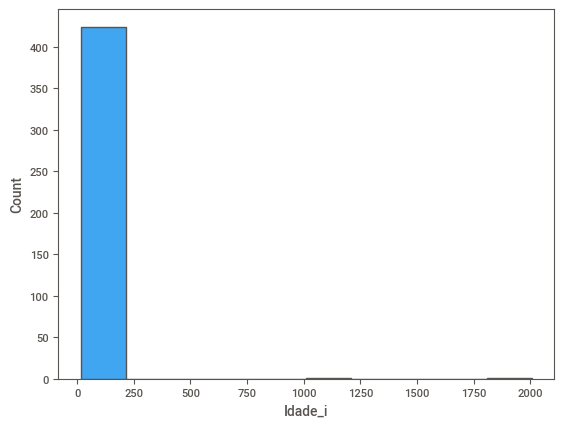

In [55]:

sb.histplot(x="Idade_i", data=cadastro, bins=10);

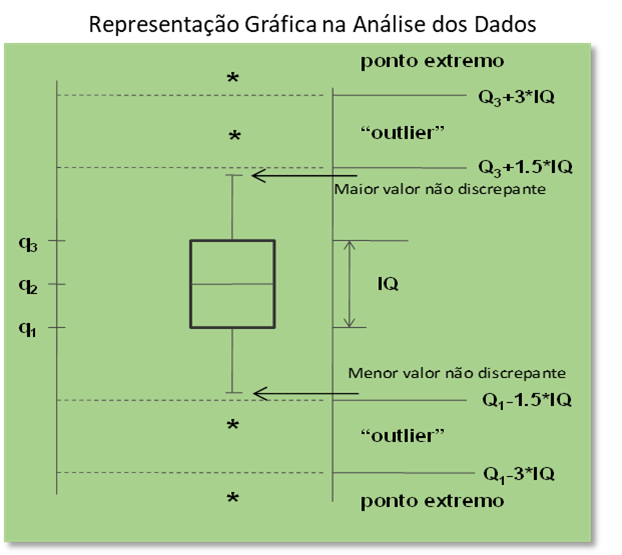

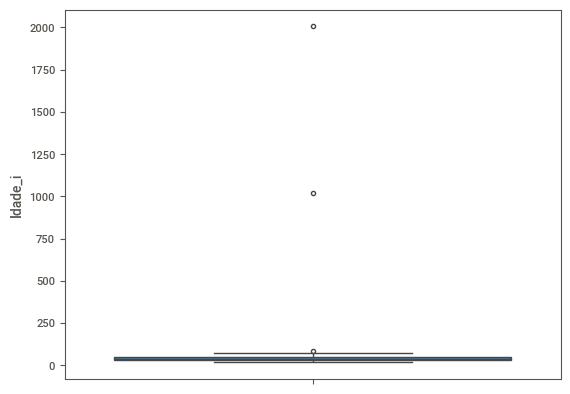

In [56]:
sb.boxplot(y="Idade_i", data=cadastro);

In [84]:
# opção sobre como eliminar outliers é achatamento de algum valor descrepante

#1 cadastro.loc[cadastro["Idade_i"]>=1000, "Idade_i"] = 100
cadastro.loc[cadastro["Idade_i"]>=1000, "Idade_i"] = cadastro["IDADE"].mean()


In [85]:
cadastro.describe().round(2)

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,...,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE,Idade_i,outlier_renda
count,426.00,426.00,426.00,426.00,425.00,426.00,389.00,389.00,275.00,275.00,...,170.00,308.00,308.00,308.00,421.00,426.00,426.00,421.00,426.00,426.00
mean,26830502524.11,213.50,10387.81,4635212.33,595.29,4635212.33,-23.58,-46.60,16.50,976736587.11,...,960391066.33,189.76,2570.55,51862517.85,31873758302107.56,212868.56,1.00,45.74,38.85,0.10
std,19135846183.67,123.12,111783.91,1978839.32,4869.60,1978839.32,0.08,0.11,17.78,56323647.16,...,138162785.25,175.78,2347.82,469016468.99,22283968587101.66,2202077.89,0.00,107.73,11.91,0.52
min,94700508.00,1.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,...,77151941.00,1.00,1.00,290.00,113451000135.00,0.00,1.00,17.00,17.00,-1.00
25%,10869067862.00,107.25,2068.50,3153250.25,58.00,3153250.25,-23.63,-46.68,11.00,969555131.50,...,973504991.25,33.00,563.25,15030.00,8623036000133.00,198.50,1.00,30.00,30.00,0.00
50%,26041138816.00,213.50,2431.58,4323120.00,164.00,4323120.00,-23.56,-46.63,11.00,982497429.00,...,982267694.50,237.00,1900.00,53951.00,40432544000147.00,360.00,1.00,37.00,37.00,0.00
75%,35798933865.00,319.75,2923.54,5644782.50,430.00,5644782.50,-23.51,-46.52,11.00,992424488.50,...,993495586.00,341.00,3781.00,488489.25,43374768000138.00,981.00,1.00,46.00,46.00,0.00
max,99921022504.00,426.00,1890000.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,...,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00,85.00,2.00


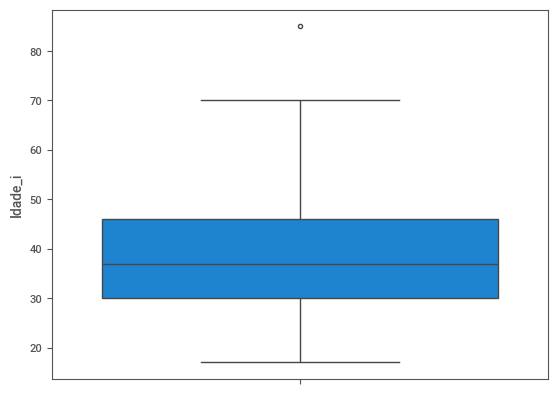

In [86]:
# O Box Plot (desenho esquemático) informa medidas de posição, dispersão, assimetria, caudas e dados atípicos (outliers).
#     A posição central é dada pela mediana e a dispersão pela amplitude inter-quartílica.
#     As medidas de posição q1, q2 e q3 informam a assimetria da distribuição.
#     Os comprimentos das caudas são dados pelas linhas que vão do retângulo aos valores distantes e pelos valores atípicos.
sb.boxplot(y="Idade_i", data=cadastro);

### Muito cuidado ao avaliar outliers vs um público específico

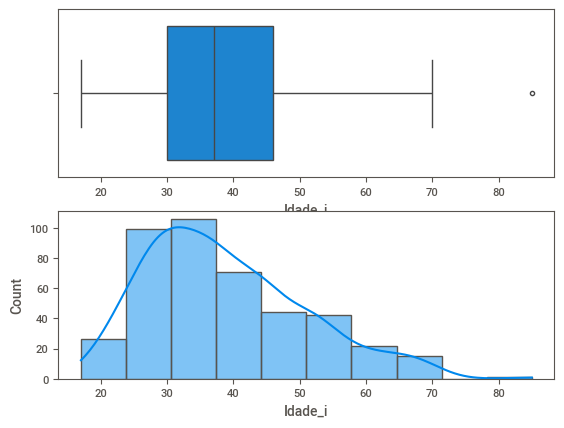

In [87]:

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="Idade_i", data=cadastro, ax=ax1)
sb.histplot(x="Idade_i", data=cadastro, bins=10, kde=True, ax=ax2)

plt.show()

In [60]:
cadastro["Idade_i"].describe()

count    426.00
mean      45.74
std      107.09
min       17.00
25%       30.00
50%       37.00
75%       46.00
max     2006.00
Name: Idade_i, dtype: float64

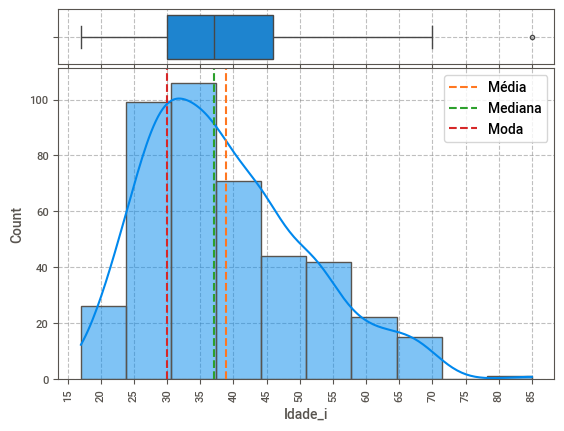

In [88]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    gridspec_kw={"height_ratios": (0.15, 0.85), "hspace": 0.02},
)

sb.boxplot(x="Idade_i", data=cadastro, ax=ax1)
sb.histplot(x="Idade_i", data=cadastro, bins=10, kde=True, ax=ax2)

ax2.xaxis.set_major_locator(mtick.MultipleLocator(base=5.0))
ax2.tick_params(axis="x", rotation=90)

for ax in (ax1, ax2):
    ax.grid(True, linestyle="--", color="gray", alpha=0.5)
    ax.set_axisbelow(True)

ax2.axvline(cadastro["Idade_i"].mean(), color="C1", linestyle="--", label="Média")
ax2.axvline(cadastro["Idade_i"].median(), color="C2", linestyle="--", label="Mediana")
ax2.axvline(cadastro["Idade_i"].mode()[0], color="C3", linestyle="--", label="Moda")

ax2.legend()

plt.show()

## Analisando a Variável renda Presumida

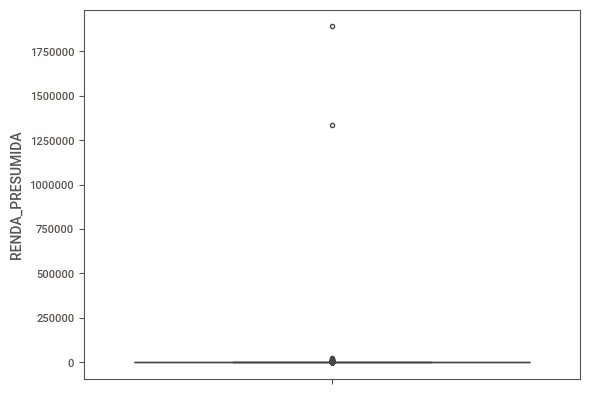

In [62]:
sb.boxplot(y="RENDA_PRESUMIDA", data=cadastro);

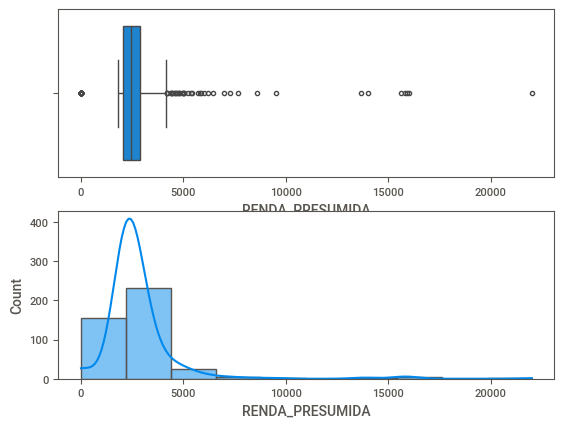

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE,Idade_i
count,424.00,424.00,424.00,424.00,423.00,424.00,389.00,389.00,273.00,273.00,169.00,169.00,307.00,307.00,307.00,419.00,424.00,424.00,419.00,424.00
mean,26689321176.27,214.50,2833.29,4648137.81,597.57,4648137.81,-23.58,-46.60,16.54,976750753.23,18.30,960241224.30,189.26,2557.52,52031402.13,31920393513569.51,213870.13,1.00,45.80,45.80
std,19038868598.23,122.54,2090.98,1974102.62,4881.01,1974102.62,0.08,0.11,17.84,56529763.77,19.63,138559518.96,175.86,2340.47,469772830.22,22290915450330.06,2207229.09,0.00,107.98,107.34
min,94700508.00,3.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,11.00,77151941.00,1.00,1.00,290.00,113451000135.00,0.00,1.00,17.00,17.00
25%,10690190351.00,108.75,2068.00,3166001.00,59.00,3166001.00,-23.63,-46.68,11.00,969493587.00,11.00,973494957.00,33.00,560.50,15033.50,8623036000133.00,198.00,1.00,30.00,30.00
50%,25821262314.00,214.50,2430.00,4323120.00,164.00,4323120.00,-23.56,-46.63,11.00,982536548.00,11.00,982186579.00,237.00,1898.00,54094.00,40432544000147.00,360.00,1.00,37.00,37.00
75%,35611337107.50,320.25,2898.58,5661025.00,430.50,5661025.00,-23.51,-46.52,11.00,992489528.00,11.00,993495586.00,341.00,3775.00,492822.50,43374768000138.00,981.00,1.00,46.00,46.00
max,99921022504.00,426.00,22000.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,98.00,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00,2006.00


In [63]:
# excluindo renda presumida acima de 100mil
renda = cadastro[(cadastro['RENDA_PRESUMIDA'] <100000)]

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=renda, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=renda, bins=10, kde=True, ax=ax2)

plt.show()
renda.describe().round(2)

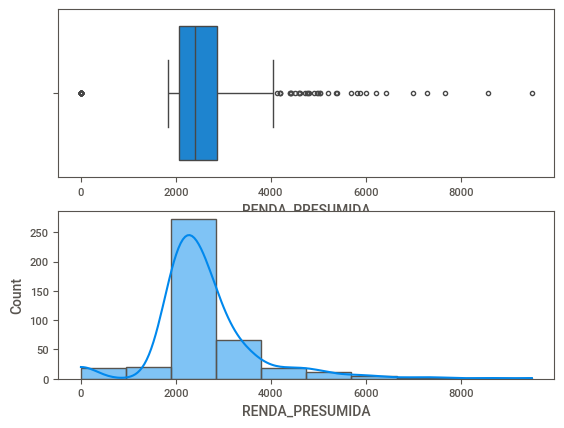

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE,Idade_i
count,417.00,417.00,417.00,417.00,416.00,417.00,382.00,382.00,268.00,268.00,166.00,166.00,300.00,300.00,300.00,415.00,417.00,417.00,415.00,417.00
mean,26837760811.41,218.00,2609.89,4647081.85,596.06,4647081.85,-23.58,-46.60,16.41,976966433.66,18.05,959736823.02,187.08,2540.88,53201324.18,31931618465506.11,217457.48,1.00,45.80,45.80
std,18748928146.71,120.52,1142.84,1978840.79,4921.68,1978840.79,0.08,0.11,17.63,56952999.85,19.29,139758595.46,174.26,2337.10,475176371.06,22310250348263.56,2225546.52,0.00,108.49,108.23
min,276815300.00,10.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,11.00,77151941.00,1.00,1.00,290.00,113451000135.00,0.00,1.00,17.00,17.00
25%,11376936810.00,114.00,2066.66,3166001.00,57.00,3166001.00,-23.63,-46.68,11.00,969807748.25,11.00,973438281.75,30.00,554.75,14750.25,8623036000133.00,200.00,1.00,30.00,30.00
50%,26269819822.00,218.00,2412.00,4323120.00,160.00,4323120.00,-23.56,-46.63,11.00,983140279.50,11.00,982092947.00,237.00,1892.50,53279.00,41218363000185.00,368.00,1.00,37.00,37.00
75%,35798933865.00,322.00,2861.04,5661040.00,420.00,5661040.00,-23.51,-46.51,11.00,992516161.50,11.00,993495586.00,341.00,3773.00,411182.75,43374768000138.00,981.00,1.00,46.00,46.00
max,99921022504.00,426.00,9500.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,98.00,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00,2006.00


In [64]:
# ecluindo renda presumida acima de 10mil
renda = cadastro[(cadastro['RENDA_PRESUMIDA'] <10000)]

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=renda, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=renda, bins=10, kde=True, ax=ax2)

plt.show()
renda.describe().round(2)

#### Exluindo as observações acima de 10.000 ficamos com 417 observações mas esse é o melhor corte?

### Trabalhando com o BoxPLot

    Box Plot da Renda Presumida
    mínimo =  
    máximo =  
    Quartil 1 (Q1) =  
    Quartil 2 (Q2) =  
    Quartil 3 (Q3) =  
    Inter-quartil = Q3 - Q1 =  

    Limite1  = Q3 + 3 * IQ =  
    Limite2  = Q3 + 1.5*IQ =  
    Limite3  = Q1 - 1.5*IQ =  
    Limite4  = Q1 - 3*IQ =  

In [65]:
cadastro.describe().round(2)

,NUM_CPF,CHAVE_CONTRATO,RENDA_PRESUMIDA,CEP,NUMERO,CEP_A,LATITUDE,LONGITUDE,DDD_CELULAR,CELULAR,DDD_CELULAR_2,CELULAR_2,COD_BANCO,NUM_AGENCIA,NUM_CONTA,CNPJ_CREDOR,VALOR_DIVIDA,STATUS_CONSENTIMENTO,IDADE,Idade_i
count,426.00,426.00,426.00,426.00,425.00,426.00,389.00,389.00,275.00,275.00,170.00,170.00,308.00,308.00,308.00,421.00,426.00,426.00,421.00,426.00
mean,26830502524.11,213.50,10387.81,4635212.33,595.29,4635212.33,-23.58,-46.60,16.50,976736587.11,18.26,960391066.33,189.76,2570.55,51862517.85,31873758302107.56,212868.56,1.00,45.74,45.74
std,19135846183.67,123.12,111783.91,1978839.32,4869.60,1978839.32,0.08,0.11,17.78,56323647.16,19.58,138162785.25,175.78,2347.82,469016468.99,22283968587101.66,2202077.89,0.00,107.73,107.09
min,94700508.00,1.00,0.00,1007020.00,3.00,1007020.00,-23.80,-46.81,11.00,78462120.00,11.00,77151941.00,1.00,1.00,290.00,113451000135.00,0.00,1.00,17.00,17.00
25%,10869067862.00,107.25,2068.50,3153250.25,58.00,3153250.25,-23.63,-46.68,11.00,969555131.50,11.00,973504991.25,33.00,563.25,15030.00,8623036000133.00,198.50,1.00,30.00,30.00
50%,26041138816.00,213.50,2431.58,4323120.00,164.00,4323120.00,-23.56,-46.63,11.00,982497429.00,11.00,982267694.50,237.00,1900.00,53951.00,40432544000147.00,360.00,1.00,37.00,37.00
75%,35798933865.00,319.75,2923.54,5644782.50,430.00,5644782.50,-23.51,-46.52,11.00,992424488.50,11.00,993495586.00,341.00,3781.00,488489.25,43374768000138.00,981.00,1.00,46.00,46.00
max,99921022504.00,426.00,1890000.00,8490018.00,99999.00,8490018.00,-23.43,-46.38,98.00,999993969.00,98.00,999889639.00,756.00,9270.00,6500059293.00,96367305000105.00,28072009.00,1.00,2006.00,2006.00


In [66]:
print('Minimo = ', min(cadastro['RENDA_PRESUMIDA']))

Minimo =  0.0


In [67]:
print('Maximo = ', max(cadastro['RENDA_PRESUMIDA']))

Maximo =  1890000.0


In [68]:
Q1 = np.percentile(cadastro['RENDA_PRESUMIDA'], 25)
print(Q1)
print('Quartil1 (Q1) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 25))

2068.5
Quartil1 (Q1) =  2068.5


In [69]:
Q2=np.percentile(cadastro['RENDA_PRESUMIDA'], 50)
print(Q2)
print('Quartil2 (Q2) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 50))

2431.58
Quartil2 (Q2) =  2431.58


In [70]:
Q3=np.percentile(cadastro['RENDA_PRESUMIDA'], 75)
print(Q3)
print('Quartil3 (Q3) = ', np.percentile(cadastro['RENDA_PRESUMIDA'], 75))

2923.545
Quartil3 (Q3) =  2923.545


In [71]:
# distância Inter-quartílica

IQ = np.percentile(cadastro['RENDA_PRESUMIDA'], 75) - np.percentile(cadastro['RENDA_PRESUMIDA'], 25)
print(IQ)
print('Inter-quartil (IQ) =', np.percentile(cadastro['RENDA_PRESUMIDA'], 75) - np.percentile(cadastro['RENDA_PRESUMIDA'], 25))

855.0450000000001
Inter-quartil (IQ) = 855.0450000000001


In [72]:
limite1 = Q3+3*IQ
print(limite1)

5488.68


In [73]:
limite2 = Q3+1.5*IQ
print(limite2)

4206.1125


In [74]:
limite3=Q1-1.5*IQ
print(limite3)

785.9324999999999


In [75]:
limite4 = Q1-3*IQ
print(limite4)

-496.6350000000002


In [76]:
# Quantos outliers? Pontos extremos?
print('Outliers Superior: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite2) & (cadastro.RENDA_PRESUMIDA <= limite1), 'RENDA_PRESUMIDA'].count())
print('Outliers Inferior: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite4) & (cadastro.RENDA_PRESUMIDA <= limite3), 'RENDA_PRESUMIDA'].count())
print('Pontos Extremos: ', cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite1) | (cadastro.RENDA_PRESUMIDA <= limite4), 'RENDA_PRESUMIDA'].count())


Outliers Superior:  20
Outliers Inferior:  18
Pontos Extremos:  20


In [77]:
# Criar uma variável outlier_renda no Data Frame, sendo 0 = não outlier, 1= outlier e 2 = ponto extremo
cadastro.loc[(cadastro.RENDA_PRESUMIDA >= limite2) & (cadastro.RENDA_PRESUMIDA <= limite1), 'outlier_renda']=1
cadastro.loc[(cadastro.RENDA_PRESUMIDA <= limite3) & (cadastro.RENDA_PRESUMIDA >= limite4), 'outlier_renda']=-1
cadastro.loc[(cadastro.RENDA_PRESUMIDA > limite1) | (cadastro.RENDA_PRESUMIDA < limite4) , 'outlier_renda']=2
cadastro.loc[(cadastro.RENDA_PRESUMIDA > limite3) & (cadastro.RENDA_PRESUMIDA < limite2), 'outlier_renda']=0

In [78]:
cadastro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NUM_CPF               426 non-null    int64  
 1   CHAVE_CONTRATO        426 non-null    int64  
 2   DATA_NASCIMENTO       426 non-null    object 
 3   RENDA_PRESUMIDA       426 non-null    float64
 4   CEP                   426 non-null    int64  
 5   LOGRADOURO            426 non-null    object 
 6   NUMERO                425 non-null    float64
 7   COMPLEMENTO           206 non-null    object 
 8   CEP_A                 426 non-null    int64  
 9   BAIRRO                390 non-null    object 
 10  CIDADE                426 non-null    object 
 11  UF                    426 non-null    object 
 12  LATITUDE              389 non-null    float64
 13  LONGITUDE             389 non-null    float64
 14  DDD_CELULAR           275 non-null    float64
 15  CELULAR               2

In [79]:
# Tabela de frequência da variável outlier_renda
freq_outlier_renda = pd.pivot_table(cadastro,index='outlier_renda', values='NUM_CPF', aggfunc=np.count_nonzero)
freq_outlier_renda['%'] = ((pd.pivot_table(cadastro,index='outlier_renda', values='NUM_CPF', aggfunc=np.count_nonzero)/cadastro['NUM_CPF'].count())*100).round(2)

In [80]:
# quantidade de observações
print(freq_outlier_renda)

               NUM_CPF     %
outlier_renda               
-1.00               18  4.23
0.00               368 86.38
1.00                20  4.69
2.00                20  4.69


# Um ponto de atenção aqui!!!

## Quantidade de outliers

In [81]:
################################################
########### REMOVER OS OUTLIERS ############
################################################

# Removendo os Outliers
cadastroSemOutlier = cadastro.loc[cadastro.outlier_renda == 0.0]

print('Mínimo = ', min(cadastroSemOutlier['RENDA_PRESUMIDA']))

print('Máximo = ', max(cadastroSemOutlier['RENDA_PRESUMIDA']))

print('Média = ', (cadastroSemOutlier['RENDA_PRESUMIDA']).mean())

print('STD = ', cadastroSemOutlier['RENDA_PRESUMIDA'].std())

print('Coeficiente de Variação = ', (cadastroSemOutlier['RENDA_PRESUMIDA'].std() / cadastroSemOutlier['RENDA_PRESUMIDA'].mean()))

print('Mediana = ', (cadastroSemOutlier['RENDA_PRESUMIDA']).median())


Mínimo =  1825.32
Máximo =  4200.0
Média =  2489.861630434783
STD =  517.4251707755459
Coeficiente de Variação =  0.20781282158446387
Mediana =  2400.0


Text(0.5, 0, 'RENDA_PRESUMIDA SEM OUTLIERS(R$)')

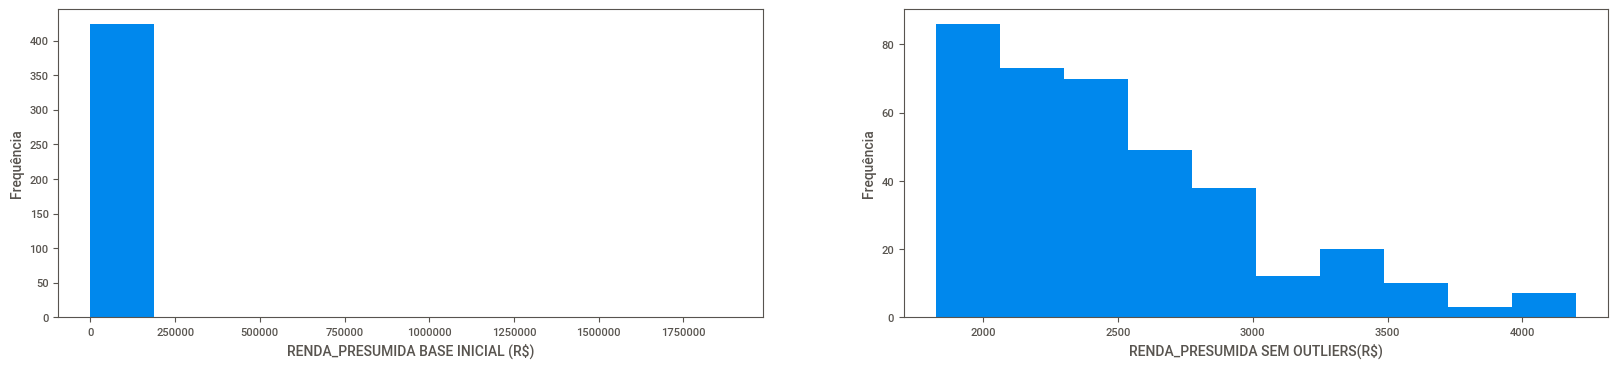

In [82]:
# Gráfico histograma  Antes e Depois
fig, axes = plt.subplots(nrows=1, ncols=2,figsize=(20,4))

plt.subplot(1,2,1)
plt.hist(cadastro['RENDA_PRESUMIDA'], bins=10)
plt.ylabel('Frequência')
plt.xlabel('RENDA_PRESUMIDA BASE INICIAL (R$)')
plt.subplot(1,2,2)
plt.hist(cadastroSemOutlier['RENDA_PRESUMIDA'], bins=10)
plt.ylabel('Frequência')
plt.xlabel('RENDA_PRESUMIDA SEM OUTLIERS(R$)')

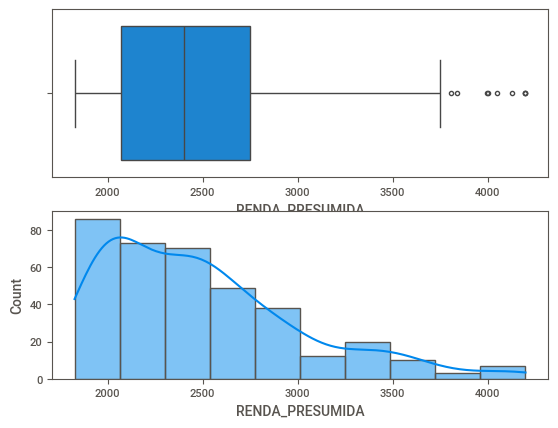

In [83]:
# Resultado da análise

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1)

sb.boxplot(x="RENDA_PRESUMIDA", data=cadastroSemOutlier, ax=ax1)
sb.histplot(x="RENDA_PRESUMIDA", data=cadastroSemOutlier, bins=10, kde=True, ax=ax2)

plt.show()